In [19]:
import pandas as pd

file_path = "../chapter04/data/btc_usdt_1d.csv"

df = pd.read_csv(
    file_path,
    parse_dates=["timestamp"],
    index_col="timestamp",
)

df = df.sort_index()

print(df.head())
print(df.tail())

                               open      high       low     close       volume
timestamp                                                                     
2025-08-28 00:00:00+00:00  111254.1  113484.9  110869.6  112564.0  5118.996882
2025-08-29 00:00:00+00:00  112564.1  112642.0  107474.9  108385.7  7323.836956
2025-08-30 00:00:00+00:00  108385.8  108922.9  107343.7  108815.0  4987.664210
2025-08-31 00:00:00+00:00  108815.1  109486.0  108064.9  108248.3  2305.232282
2025-09-01 00:00:00+00:00  108248.0  109911.0  107250.0  109235.9  4341.712476
                              open     high      low    close       volume
timestamp                                                                 
2026-06-19 00:00:00+00:00  62953.3  63664.0  62310.1  63541.0  5700.907189
2026-06-20 00:00:00+00:00  63541.0  64384.5  63200.0  64300.0  7039.788795
2026-06-21 00:00:00+00:00  64300.1  64594.0  63262.0  63313.0  6447.301976
2026-06-22 00:00:00+00:00  63313.1  65629.5  63313.1  64027.6  6066.3150

In [20]:
df["ma20"] = df["close"].rolling(window=20).mean()
df["ma60"] = df["close"].rolling(window=60).mean()
df["trend_up"] = df["ma20"] > df["ma60"]

In [21]:
previous_ma20 = df["ma20"].shift(1)
previous_ma60 = df["ma60"].shift(1)

df["buy_signal"] = (
    (previous_ma20 <= previous_ma60)
    & (df["ma20"] > df["ma60"])
)

df["sell_signal"] = (
    (previous_ma20 >= previous_ma60)
    & (df["ma20"] < df["ma60"])
)

In [22]:
df["target_position"] = pd.Series(
    index=df.index,
    dtype="float",
)

df.loc[df["buy_signal"], "target_position"] = 1
df.loc[df["sell_signal"], "target_position"] = 0

df["position"] = (
    df["target_position"]
    .ffill()
    .fillna(0)
    .shift(1, fill_value=0)
    .astype(int)
)

print(df[["buy_signal", "sell_signal", "position"]].tail())

                           buy_signal  sell_signal  position
timestamp                                                   
2026-06-19 00:00:00+00:00       False        False         0
2026-06-20 00:00:00+00:00       False        False         0
2026-06-21 00:00:00+00:00       False        False         0
2026-06-22 00:00:00+00:00       False        False         0
2026-06-23 00:00:00+00:00       False        False         0


In [23]:
df["open_to_next_open_return"] = (
    df["open"].shift(-1) / df["open"] - 1
)

In [24]:
df["strategy_return"] = (
    df["position"] * df["open_to_next_open_return"]
)

In [25]:
df["benchmark_return"] = df["open_to_next_open_return"]

In [26]:
backtest = df.dropna(
    subset=["open_to_next_open_return"]
).copy()

In [27]:
backtest = backtest.loc[
    backtest["ma60"].notna()
].copy()

In [28]:
initial_cash = 1000

In [29]:
backtest["strategy_equity"] = (
    initial_cash
    * (1 + backtest["strategy_return"]).cumprod()
)

In [30]:
backtest["benchmark_equity"] = (
    initial_cash
    * (1 + backtest["benchmark_return"]).cumprod()
)

In [31]:
print(backtest[[
    "strategy_return",
    "benchmark_return",
    "strategy_equity",
    "benchmark_equity",
]].tail())

                           strategy_return  benchmark_return  strategy_equity  \
timestamp                                                                       
2026-06-18 00:00:00+00:00             -0.0         -0.024009       804.396937   
2026-06-19 00:00:00+00:00              0.0          0.009335       804.396937   
2026-06-20 00:00:00+00:00              0.0          0.011947       804.396937   
2026-06-21 00:00:00+00:00             -0.0         -0.015350       804.396937   
2026-06-22 00:00:00+00:00              0.0          0.011285       804.396937   

                           benchmark_equity  
timestamp                                    
2026-06-18 00:00:00+00:00        563.845052  
2026-06-19 00:00:00+00:00        569.108822  
2026-06-20 00:00:00+00:00        575.907747  
2026-06-21 00:00:00+00:00        567.067622  
2026-06-22 00:00:00+00:00        573.467085  


In [32]:
strategy_total_return = (
    backtest["strategy_equity"].iloc[-1] / initial_cash - 1
)

benchmark_total_return = (
    backtest["benchmark_equity"].iloc[-1] / initial_cash - 1
)

print(f"策略累计收益率：{strategy_total_return:.2%}")
print(f"买入持有收益率：{benchmark_total_return:.2%}")

策略累计收益率：-19.56%
买入持有收益率：-42.65%


In [33]:
def calculate_drawdown(equity_curve):
    historical_peak = equity_curve.cummax()
    drawdown = equity_curve / historical_peak - 1
    return drawdown

In [34]:
backtest["strategy_drawdown"] = calculate_drawdown(
    backtest["strategy_equity"]
)

backtest["benchmark_drawdown"] = calculate_drawdown(
    backtest["benchmark_equity"]
)

strategy_max_drawdown = backtest["strategy_drawdown"].min()
benchmark_max_drawdown = backtest["benchmark_drawdown"].min()

print(f"策略最大回撤：{strategy_max_drawdown:.2%}")
print(f"买入持有最大回撤：{benchmark_max_drawdown:.2%}")

策略最大回撤：-24.24%
买入持有最大回撤：-46.85%


In [35]:
buy_count = backtest["buy_signal"].sum()
sell_count = backtest["sell_signal"].sum()
trade_count = buy_count + sell_count

print(f"买入次数：{buy_count}")
print(f"卖出次数：{sell_count}")
print(f"交易信号总数：{trade_count}")

买入次数：3
卖出次数：3
交易信号总数：6


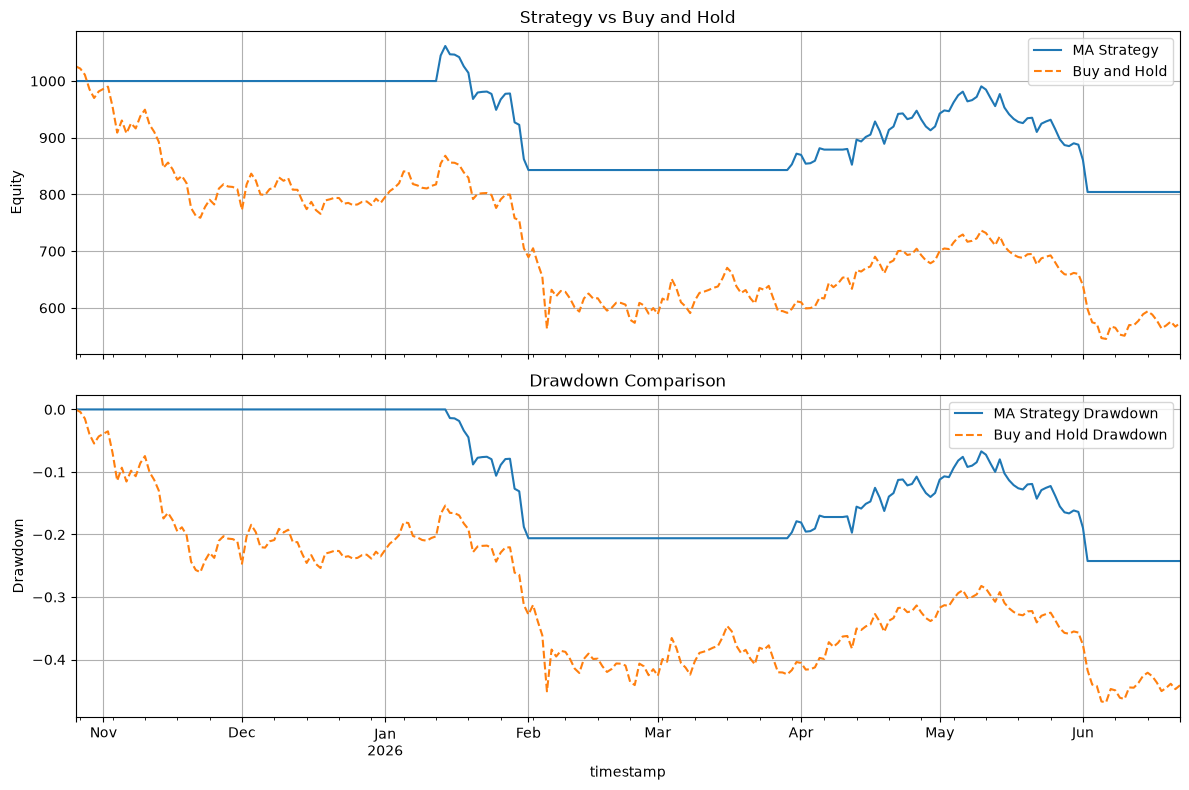

In [36]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True,
)

backtest["strategy_equity"].plot(
    ax=axes[0],
    label="MA Strategy",
)

backtest["benchmark_equity"].plot(
    ax=axes[0],
    label="Buy and Hold",
    linestyle="--",
)

axes[0].set_title("Strategy vs Buy and Hold")
axes[0].set_ylabel("Equity")
axes[0].grid(True)
axes[0].legend()

backtest["strategy_drawdown"].plot(
    ax=axes[1],
    label="MA Strategy Drawdown",
)

backtest["benchmark_drawdown"].plot(
    ax=axes[1],
    label="Buy and Hold Drawdown",
    linestyle="--",
)

axes[1].set_title("Drawdown Comparison")
axes[1].set_ylabel("Drawdown")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()

In [37]:
print(f"策略最大回撤：{strategy_max_drawdown:.2%}")
print(f"买入持有最大回撤：{benchmark_max_drawdown:.2%}")
print(f"买入次数：{buy_count}")
print(f"卖出次数：{sell_count}")

策略最大回撤：-24.24%
买入持有最大回撤：-46.85%
买入次数：3
卖出次数：3
